In [96]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cf

In [30]:
hist = xr.open_dataset("output/_hist_5day_.nc").compute().histogram_lon_lat
hist

<xarray.DataArray 'histogram_lon_lat' (obs: 37, lon: 29, lat: 29,
                                       start_year: 4, start_month: 12,
                                       start_day: 6)> Size: 72MB
array([[[[[[ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           ...,
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.]],

          [[ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           ...,
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.]],

          [[ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           ...,
...
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.]],

          [[ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           ...,
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.]],

          [[ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           ...,
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.],
           [ 0.,  0.,  0.,  0.,  0.,  0.]]]]]],
      shape=(37, 29, 29, 4, 12, 6))
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * start_day    (start_day) float64 48B 5.0 10.0 15.0 20.0 25.0 30.0
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float32 116B -88.2 -85.11 -82.01 ... -7.737 -4.642 -1.548
  * lat          (lat) float32 116B -5.438 -4.227 -3.016 ... 26.05 27.26 28.47

In [31]:
import cartopy
import matplotlib.pyplot as plt
import cmocean as cm

### Sea Surface Height 5 days after the release

In [32]:
ssh5 = xr.open_dataset('output/ssh_5d_avg.nc')
ssh5 = ssh5.drop_sel(time='2022-06-01')
ssh5 = ssh5.assign_coords(start_year=ssh5.time.dt.year)
ssh5 = ssh5.assign_coords(start_month=ssh5.time.dt.month)
ssh5 = ssh5.assign_coords(start_day=ssh5.time.dt.day)
ssh5

<xarray.Dataset> Size: 360MB
Dimensions:      (latitude: 372, longitude: 1026, time: 236)
Coordinates:
    depth        float32 4B ...
  * latitude     (latitude) float32 1kB -4.333 -4.25 -4.167 ... 26.42 26.5 26.58
  * longitude    (longitude) float32 4kB -87.0 -86.92 -86.83 ... -1.667 -1.583
  * time         (time) datetime64[ns] 2kB 2022-06-06 2022-06-11 ... 2025-08-24
    start_year   (time) int64 2kB 2022 2022 2022 2022 ... 2025 2025 2025 2025
    start_month  (time) int64 2kB 6 6 6 6 6 7 7 7 7 7 7 ... 7 7 7 7 7 8 8 8 8 8
    start_day    (time) int64 2kB 6 11 16 21 26 1 6 11 ... 20 25 30 4 9 14 19 24
Data variables:
    zos          (time, latitude, longitude) float32 360MB ...

In [33]:
d5 = np.tile([5, 10, 15, 20, 25, 30], (len(ssh5.time.dt.day) + 5) // 6)[:len(ssh5.time.dt.day)]

ssh5 = ssh5.assign_coords(start_day=('time', d5))
ssh5_day = ssh5.groupby(['start_year','start_month','start_day']).mean()
ssh5_day

<xarray.Dataset> Size: 440MB
Dimensions:      (start_year: 4, start_month: 12, start_day: 6, latitude: 372,
                  longitude: 1026)
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * start_day    (start_day) int64 48B 5 10 15 20 25 30
    depth        float32 4B 0.494
  * latitude     (latitude) float32 1kB -4.333 -4.25 -4.167 ... 26.42 26.5 26.58
  * longitude    (longitude) float32 4kB -87.0 -86.92 -86.83 ... -1.667 -1.583
Data variables:
    zos          (latitude, longitude, start_year, start_month, start_day) float32 440MB ...

#### Stream plot U,V calculation from SSH 5 days

In [37]:
def ssh_stream_vectors(ssh2d):
    """
    Compute a vector field tangent to SSH contours for streamplot.

    Parameters
    ----------
    ssh2d : 2D array-like
        Sea surface height for a single time (and level), shape (ny, nx).

    Returns
    -------
    U, V : 2D numpy arrays
        Components suitable for plt.streamplot(lon, lat, U, V) in index space:
        U = -d(ssh)/dy, V = d(ssh)/dx
    """
    ETA = np.asarray(ssh2d)
    dETA_dy = np.gradient(ETA, axis=0)
    dETA_dx = np.gradient(ETA, axis=1)
    U = -dETA_dy
    V =  dETA_dx
    return U, V

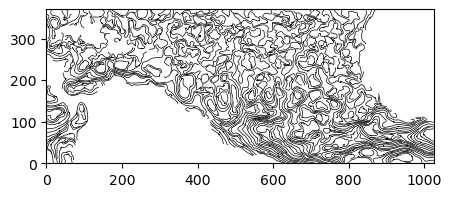

In [38]:
syr = 2024
smon =3 
sday =25 

ssh2d = ssh5_day.zos.sel(start_year=syr, start_month=smon, start_day=sday).squeeze()
U, V = ssh_stream_vectors(ssh2d)

ny, nx = U.shape
x = np.arange(nx)
y = np.arange(ny)


fig, ax = plt.subplots(figsize=(5,2))
ax.streamplot(x, y, U, V, color='k', density=7, arrowsize=0.1, linewidth=0.5)
plt.show()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


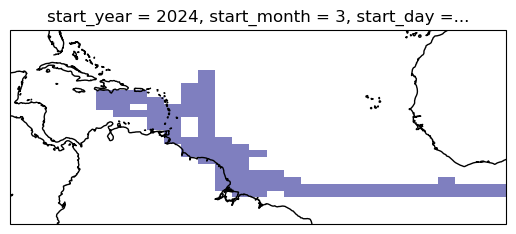

In [105]:
#
alpha = 0.65  # 0..1
navy = (0/255, 0/255, 128/255, alpha)  # RGBA for navy

bluenavy_ = mpl.colors.ListedColormap([navy])
data = hist.sel(start_year=2024, start_month=3, start_day=25).sum("obs")

##plot
ax = plt.axes(projection=cartopy.crs.PlateCarree())
np.log10(data).plot(
                x="lon", y="lat",
                transform=cartopy.crs.PlateCarree(), ax=ax,
                add_colorbar=False,cmap=bluenavy_
            )
ax.coastlines()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


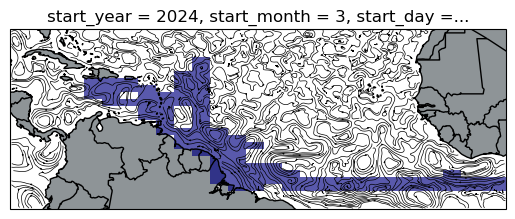

In [108]:
import matplotlib as mpl

syr = 2024
smon =3 
sday =25 

ssh2d = ssh5_day.zos.sel(start_year=syr, start_month=4, start_day=5).squeeze()
U, V = ssh_stream_vectors(ssh2d)

ny, nx = U.shape
x = np.arange(nx)
y = np.arange(ny)


da = hist.sel(start_year=2024, start_month=3, start_day=25).sum("obs")

# Streamplot of U,V on same lon/lat grid (1D, equally spaced)
lon = ssh2d['longitude'].values  # replace with your lon 1D
lat = ssh2d['latitude'].values   # replace with your lat 1D

## plot
ax = plt.axes(projection=ccrs.PlateCarree())
np.log10(da).plot(x="lon", y="lat", transform=ccrs.PlateCarree(), ax=ax, add_colorbar=False,cmap=bluenavy_)
strm = ax.streamplot(lon, lat, U, V,
                     transform=ccrs.PlateCarree(),  # tell Cartopy the data CRS
                     color='k', density=7, arrowsize=0.2, linewidth=0.5)

ax.coastlines()
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
ax.add_feature(cf.BORDERS)
ax.add_feature(cf.LAND, facecolor='#8e9497ff')
plt.show()

#### Extreme case in 
syr = 2024
smon =3 
sday =25 

In [112]:
# Example: da, lon, lat, U, V, bluenavy_ already defined
def plot_panel(ax, da, lon, lat, U, V, title=None):
    # Background
    np.log10(da).plot(
        x="lon", y="lat",
        transform=ccrs.PlateCarree(), ax=ax,
        add_colorbar=False, cmap=bluenavy_
    )
    # Streamlines
    ax.streamplot(
        lon, lat, U, V,
        transform=ccrs.PlateCarree(),
        color='k', density=6, arrowsize=0.1, linewidth=0.5
    )
    # Map features
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m')
    ax.add_feature(cf.BORDERS, linewidth=0.5)
    ax.add_feature(cf.LAND, facecolor='#8e9497ff', edgecolor='none')
    if title:
        ax.set_title(title, fontsize=11)

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/tmp/ipykernel_811441/2283599270.py:26: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_ad

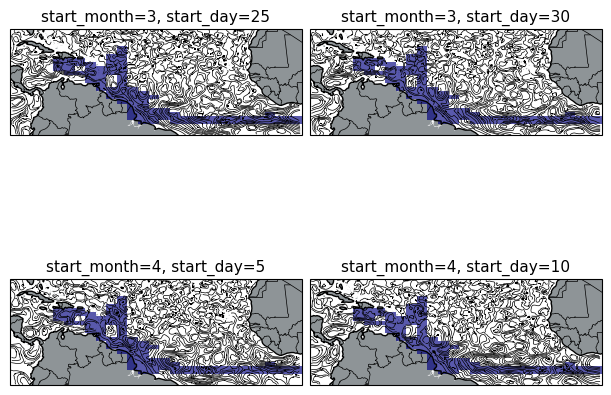

In [116]:
extent = [lon.min(), lon.max(), lat.min(), lat.max()]
## dates for ssh
ssh2d0 = ssh5_day.zos.sel(start_year=syr, start_month=3, start_day=25).squeeze()
ssh2d1 = ssh5_day.zos.sel(start_year=syr, start_month=3, start_day=30).squeeze()
ssh2d2 = ssh5_day.zos.sel(start_year=syr, start_month=4, start_day=5).squeeze()
ssh2d3 = ssh5_day.zos.sel(start_year=syr, start_month=4, start_day=10).squeeze()

U0, V0 = ssh_stream_vectors(ssh2d0)
U1, V1 = ssh_stream_vectors(ssh2d1)
U2, V2 = ssh_stream_vectors(ssh2d2)
U3, V3 = ssh_stream_vectors(ssh2d3)


fig, axs = plt.subplots(
    2, 2,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6,5),
    constrained_layout=True
)

plot_panel(axs[0, 0], da, lon, lat, U0, V0, title='start_month=3, start_day=25')
plot_panel(axs[0, 1], da, lon, lat, U1, V1, title='start_month=3, start_day=30')
plot_panel(axs[1, 0], da, lon, lat, U2, V2, title='start_month=4, start_day=5')
plot_panel(axs[1, 1], da, lon, lat, U3, V3, title='start_month=4, start_day=10')

fig.subplots_adjust(
    left=0.02, right=0.98, bottom=0.05, top=0.95,
    wspace=0.02, hspace=0.02
)

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


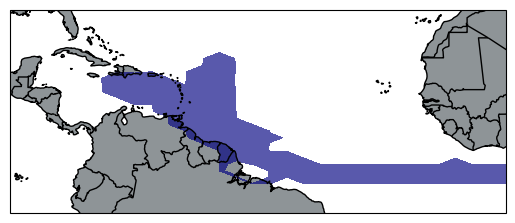

In [97]:
# syr = 2024
# smon =3 
# sday =25

# ax = plt.axes(projection=cartopy.crs.PlateCarree())

# data = hist.sel(start_year=syr, start_month=smon, start_day=sday).sum("obs")
# ax.contourf(hist.lon, hist.lat, data.T, colors= '#000080', alpha = 0.65, levels=[1,hist.max()],transform=cartopy.crs.PlateCarree()) 
# ax.coastlines()
# ax.add_feature(cf.BORDERS)
# ax.add_feature(cf.LAND, facecolor='#8e9497ff')
# plt.show()